<a href="https://colab.research.google.com/github/altafth/sat-sentiment-analysis/blob/main/SAT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Project Title: Sentiment Analysis on Text

In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Data_For_SA/train.csv', encoding = 'latin1')
print("Dataset 'train.csv' loaded successfully.")
df.head()

Dataset 'train.csv' loaded successfully.


,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346,652860.0,60
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,noon,21-30,Albania,2877797,27400.0,105
2,088c60f138,my boss is bullying me...,bullying me,negative,night,31-45,Algeria,43851044,2381740.0,18
3,9642c003ef,what interview! leave me alone,leave me alone,negative,morning,46-60,Andorra,77265,470.0,164
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,noon,60-70,Angola,32866272,1246700.0,26


# Identify irrelvant data

In [ ]:
df.isnull().sum()

,0
textID,0
text,1
selected_text,1
sentiment,0
Time of Tweet,0
Age of User,0
Country,0
Population -2020,0
Land Area (Km²),0
Density (P/Km²),0


In [ ]:
print(df.columns)

Index(['textID', 'text', 'selected_text', 'sentiment', 'Time of Tweet',
       'Age of User', 'Country', 'Population -2020', 'Land Area (Km²)',
       'Density (P/Km²)'],
      dtype='object')


#Chi-Square → Categorical variables → independence/relation test

> Add blockquote



In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency

print("--- Starting Chi-Square Contingency Tests ---")

# Identify categorical columns, excluding identifiers and the target variable itself
categorical_cols = [col for col in df.columns if df[col].dtype == 'object' and col not in ['textID', 'text', 'selected_text', 'sentiment']]
numeric_cols = [col for col in df.columns if df[col].dtype != 'object']

print(f"\nCategorical variables identified for chi-square test: {categorical_cols}")
print(f"Numeric variables identified (not suitable for direct chi-square): {numeric_cols}")

# Perform chi-square test for each categorical variable against 'sentiment'
for col in categorical_cols:
    print(f"\nAnalyzing relationship between '{col}' and 'sentiment':")
    # Create a contingency table
    contingency_table = pd.crosstab(df[col], df['sentiment'])

    # Perform Chi-Square test
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    print(f"  P-value for '{col}': {p_value:.4f}")

    # Interpret the p-value
    if p_value < 0.05:
        print(f"  Result: Reject the null hypothesis. There is a statistically significant relationship between '{col}' and 'sentiment'.")
    else:
        print(f"  Result: Fail to reject the null hypothesis. There is no statistically significant relationship between '{col}' and 'sentiment'.")

print("\n--- Explanation Regarding Numeric Variables ---")
print("Chi-square contingency tests are designed for categorical variables. They assess if there's a statistically significant association between the frequencies of categories in two or more nominal (categorical) variables.")
print("Numeric variables, by definition, represent measurable quantities and typically have many unique values, making them unsuitable for direct application in a chi-square test.")
print("\nAlternative approaches for numeric variables:")
print("1. Binning: Numeric variables can be converted into categorical variables by dividing their range into bins (e.g., 'low', 'medium', 'high'). Once binned, a chi-square test can be performed.")
print("2. ANOVA (Analysis of Variance): If you want to see if the means of a numeric variable differ across groups defined by a categorical variable (like 'sentiment'), ANOVA is appropriate.")
print("3. Kruskal-Wallis H-test: A non-parametric alternative to ANOVA, suitable if the numeric data does not meet ANOVA's assumptions (e.g., normality).")
print("4. T-tests: If the categorical variable (like 'sentiment') has only two groups, a t-test can compare the means of the numeric variable between these two groups.")

--- Starting Chi-Square Contingency Tests ---

Categorical variables identified for chi-square test: ['Time of Tweet', 'Age of User', 'Country']
Numeric variables identified (not suitable for direct chi-square): ['Population -2020', 'Land Area (Km²)', 'Density (P/Km²)']

Analyzing relationship between 'Time of Tweet' and 'sentiment':
  P-value for 'Time of Tweet': 0.6707
  Result: Fail to reject the null hypothesis. There is no statistically significant relationship between 'Time of Tweet' and 'sentiment'.

Analyzing relationship between 'Age of User' and 'sentiment':
  P-value for 'Age of User': 0.6240
  Result: Fail to reject the null hypothesis. There is no statistically significant relationship between 'Age of User' and 'sentiment'.

Analyzing relationship between 'Country' and 'sentiment':
  P-value for 'Country': 0.6336
  Result: Fail to reject the null hypothesis. There is no statistically significant relationship between 'Country' and 'sentiment'.

--- Explanation Regarding Num

#Pearson Correlation → Numerical variables → linear relationship

---



--- Performing Correlation Analysis for Numeric Variables ---

--- Correlation Matrix of Numeric Features ---


,Population -2020,Land Area (Km²),Density (P/Km²)
Population -2020,1.000000,0.453090,-0.017266
Land Area (Km²),0.453090,1.000000,-0.054046
Density (P/Km²),-0.017266,-0.054046,1.000000


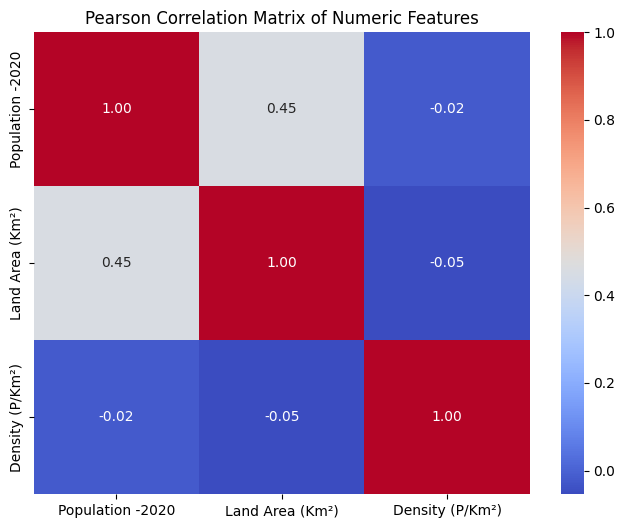


--- Interpreting Correlations ---
The correlation matrix shows the Pearson correlation coefficient between each pair of numeric variables. Values close to 1 indicate a strong positive linear relationship, values close to -1 indicate a strong negative linear relationship, and values close to 0 indicate a weak or no linear relationship.

--- Relationship between Numeric Features and Sentiment (Categorical) ---
Direct Pearson correlation is not suitable for assessing the relationship between a numeric variable and a categorical variable like 'sentiment'.
As discussed earlier, for such relationships, consider:
  - ANOVA (Analysis of Variance) if you want to compare the means of a numeric variable across different sentiment groups.
  - Visualizations like box plots or violin plots to see the distribution of numeric features for each sentiment category.


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

print("--- Performing Correlation Analysis for Numeric Variables ---")

# Filter for only numeric columns for correlation analysis
numeric_df = df[numeric_cols]

# Convert sentiment to a numerical representation if not already (e.g., for correlation with numeric features)
# For a simple linear correlation, we might need to map sentiment categories to numbers.
# However, since sentiment is categorical, a direct Pearson correlation with numeric features is not ideal.
# Instead, we can look at ANOVA or t-tests (as previously mentioned) or visualize distribution of numeric features per sentiment category.
# If we absolutely need a 'correlation', we could assign arbitrary numerical values to sentiment.
# For now, let's focus on correlations *among* numeric features, and then consider how numeric features relate to sentiment separately.

print("\n--- Correlation Matrix of Numeric Features ---")
correlation_matrix = numeric_df.corr(method='pearson')
display(correlation_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Pearson Correlation Matrix of Numeric Features')
plt.show()

print("\n--- Interpreting Correlations ---")
print("The correlation matrix shows the Pearson correlation coefficient between each pair of numeric variables. Values close to 1 indicate a strong positive linear relationship, values close to -1 indicate a strong negative linear relationship, and values close to 0 indicate a weak or no linear relationship.")

print("\n--- Relationship between Numeric Features and Sentiment (Categorical) ---")
print("Direct Pearson correlation is not suitable for assessing the relationship between a numeric variable and a categorical variable like 'sentiment'.")
print("As discussed earlier, for such relationships, consider:")
print("  - ANOVA (Analysis of Variance) if you want to compare the means of a numeric variable across different sentiment groups.")
print("  - Visualizations like box plots or violin plots to see the distribution of numeric features for each sentiment category.")


#Removed unnecessary or irrelevant data from the dataset.

In [ ]:
df.drop(columns=['textID',
    'Time of Tweet',
    'Age of User',
    'Country',
    'Population -2020',
    'Land Area (Km²)',
    'Density (P/Km²)'], inplace=True)
df.head()

,text,selected_text,sentiment
0,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,my boss is bullying me...,bullying me,negative
3,what interview! leave me alone,leave me alone,negative
4,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


# (EDA - Exploratory Data Analysis) => Perform data exploration to identify patterns and anomalies

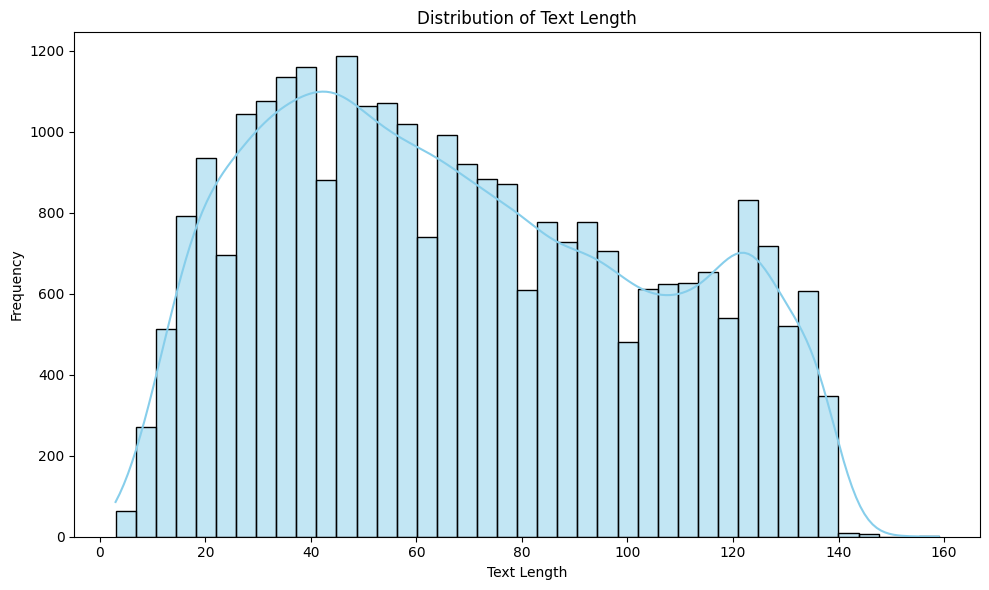

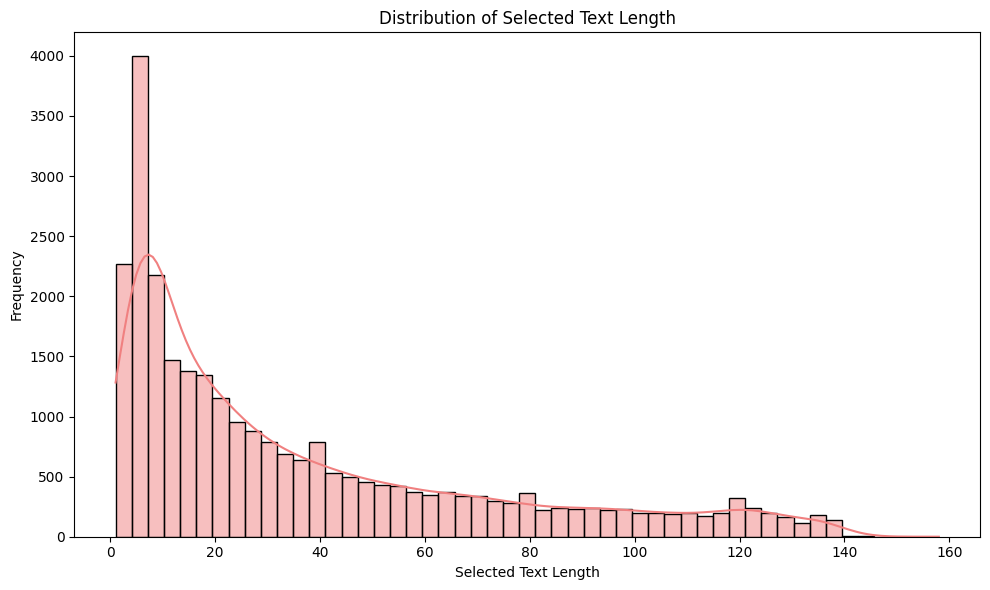

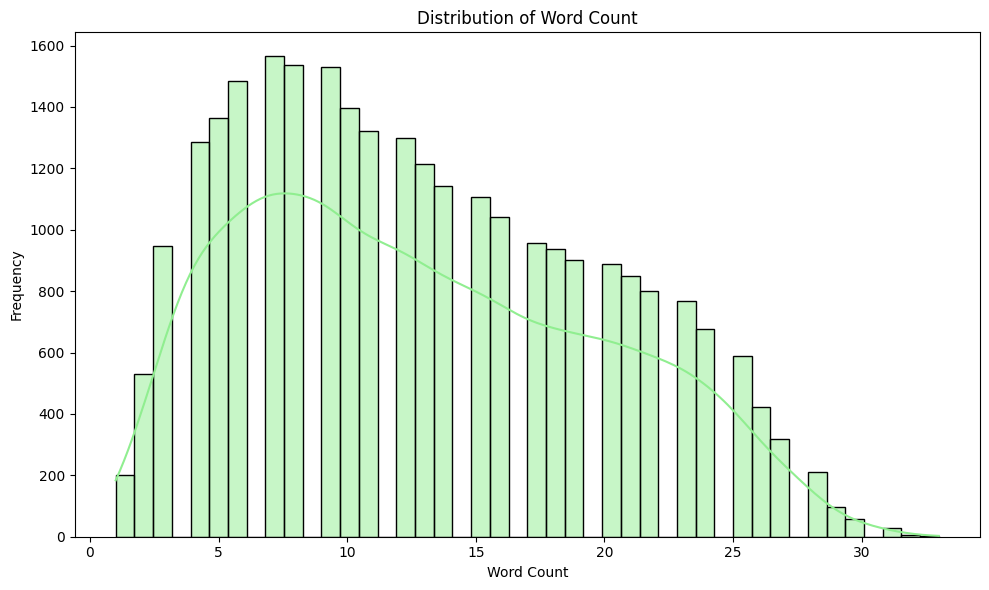

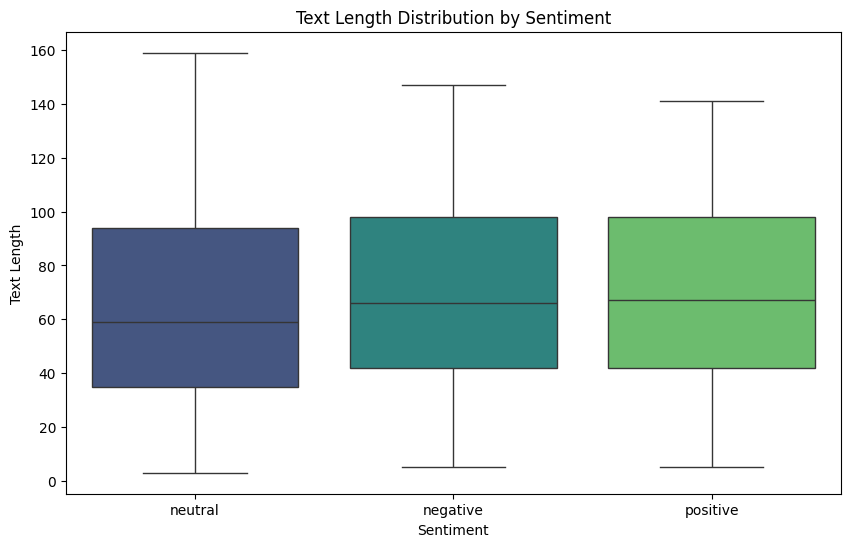




Descriptive statistics for Text Length:
count    27481.000000
mean        68.352571
std         35.625950
min          3.000000
25%         39.000000
50%         64.000000
75%         97.000000
max        159.000000
Name: text_length, dtype: float64

Descriptive statistics for Selected Text Length:
count    27481.000000
mean        36.681234
std         35.680581
min          1.000000
25%          8.000000
50%         22.000000
75%         55.000000
max        158.000000
Name: selected_text_length, dtype: float64

Descriptive statistics for Word Count:
count    27481.000000
mean        12.902442
std          6.926185
min          1.000000
25%          7.000000
50%         12.000000
75%         18.000000
max         33.000000
Name: word_count, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the length of 'text' and 'selected_text'
df['text_length'] = df['text'].astype(str).apply(len)
df['selected_text_length'] = df['selected_text'].astype(str).apply(len)

# Calculate word count for 'text'
df['word_count'] = df['text'].astype(str).apply(lambda x: len(x.split()))

# Histogram for 'text' length
plt.figure(figsize=(10, 6))
sns.histplot(df['text_length'], kde=True, color='skyblue')
plt.title('Distribution of Text Length')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print("\n\n")

# Histogram for 'selected_text' length
plt.figure(figsize=(10, 6))
sns.histplot(df['selected_text_length'], kde=True, color='lightcoral')
plt.title('Distribution of Selected Text Length')
plt.xlabel('Selected Text Length')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print("\n\n")

# Histogram for Word Count
plt.figure(figsize=(10, 6))
sns.histplot(df['word_count'], kde=True, color='lightgreen')
plt.title('Distribution of Word Count')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print("\n\n")

# Boxplot for Text Length vs Sentiment
plt.figure(figsize=(10, 6))
sns.boxplot(x='sentiment', y='text_length', data=df, palette='viridis', hue='sentiment', legend=False)
plt.title('Text Length Distribution by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Text Length')
plt.show()

print("\n\n")

print("Descriptive statistics for Text Length:")
print(df['text_length'].describe())
print("\nDescriptive statistics for Selected Text Length:")
print(df['selected_text_length'].describe())
print("\nDescriptive statistics for Word Count:")
print(df['word_count'].describe())

# Check for imbalance in the target classes

Class balance of 'sentiment' column:
sentiment
neutral     11118
positive     8582
negative     7781
Name: count, dtype: int64


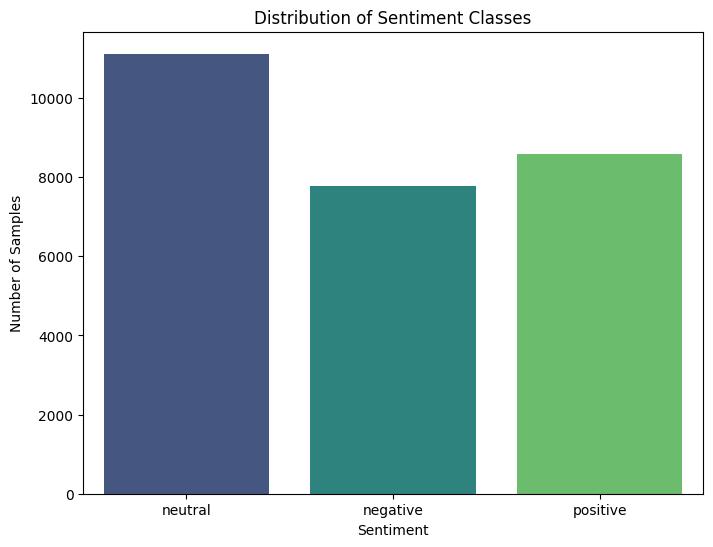

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check class balance of the target variable 'sentiment'
print("Class balance of 'sentiment' column:")
print(df['sentiment'].value_counts())

# Visualize the class balance
plt.figure(figsize=(8, 6))
sns.countplot(x='sentiment', data=df, palette='viridis', hue='sentiment', legend=False)
plt.title('Distribution of Sentiment Classes')
plt.xlabel('Sentiment')
plt.ylabel('Number of Samples')
plt.show()

# Analyze the relationship between text length and word count


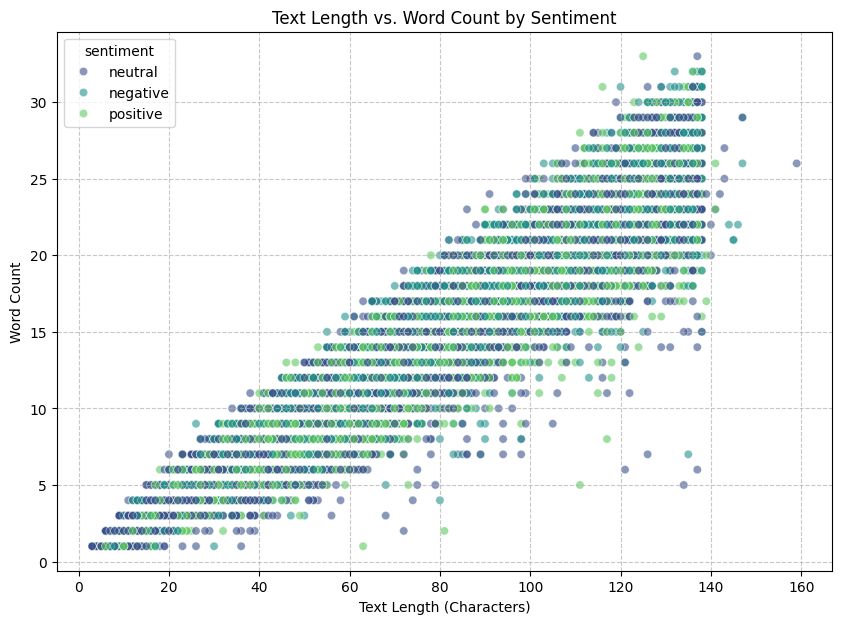

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(x='text_length', y='word_count', hue='sentiment', data=df, palette='viridis', alpha=0.6)
plt.title('Text Length vs. Word Count by Sentiment')
plt.xlabel('Text Length (Characters)')
plt.ylabel('Word Count')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#Data Preprocessing (clear, transform,...)

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
# Download necessary NLTK data (run once)
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')


stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # Handle non-string types (e.g., NaN) by converting to empty string
    if not isinstance(text, str):
        return ''
    # 1. Lowercasing
    text = text.lower()
    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # 3. Remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)
    # 4. Remove emojis
    emoji_pattern = re.compile(pattern = "[\U0001F600-\U0001F64F\U0001F300-\U0001F5FF\U0001F680-\U0001F6FF\U0001F1E0-\U0001F1FF]", flags = re.UNICODE)
    text = emoji_pattern.sub(r'', text)
    # 5. Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)
    # 6. Remove numbers (optional, depending on context)
    text = re.sub(r'\d+', '', text)
    # 7. Tokenization
    tokens = nltk.word_tokenize(text)
    # 8. Stop word removal and Lemmatization
    cleaned_tokens = []
    for token in tokens:
        if token not in stop_words:
            cleaned_tokens.append(lemmatizer.lemmatize(token))
    return ' '.join(cleaned_tokens)

# Apply preprocessing
df['cleaned_text'] = df['text'].apply(preprocess_text)
print("\nDataFrame after preprocessing:")
print(df[['text', 'cleaned_text', 'sentiment']].head())

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!



DataFrame after preprocessing:
                                                text  \
0                I`d have responded, if I were going   
1      Sooo SAD I will miss you here in San Diego!!!   
2                          my boss is bullying me...   
3                     what interview! leave me alone   
4   Sons of ****, why couldn`t they put them on t...   

                             cleaned_text sentiment  
0                      id responded going   neutral  
1                 sooo sad miss san diego  negative  
2                            bos bullying  negative  
3                   interview leave alone  negative  
4  son couldnt put release already bought  negative  


# Feature Engineering (TF-IDF)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
# Map sentiment labels to numerical values
sentiment_mapping = {'positive': 1, 'negative': 0, 'neutral': 2}
df['sentiment_numeric'] = df['sentiment'].map(sentiment_mapping)
# Split data into training and testing sets
X = df['cleaned_text']
y = df['sentiment_numeric']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,
stratify=y)
# Initialize TF-IDF Vectorizer
# max_features: Limits the number of features (words) to consider, helping with dimensionality.
# min_df: Ignores words that appear in less than 'min_df' proportion of documents.
# max_df: Ignores words that appear in more than 'max_df' proportion of documents.
tfidf_vectorizer = TfidfVectorizer(max_features=5000, min_df=5, max_df=0.7)
# Fit and transform the training data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
# Transform the test data (do not fit again)
X_test_tfidf = tfidf_vectorizer.transform(X_test)
print(f"\nShape of X_train_tfidf: {X_train_tfidf.shape}")
print(f"Shape of X_test_tfidf: {X_test_tfidf.shape}")


Shape of X_train_tfidf: (21984, 3361)
Shape of X_test_tfidf: (5497, 3361)


# Model Selection (Logistic Regression, )

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

# Initialize Logistic Regression model
# solver='liblinear' is a good choice for smaller datasets and for multiclass problems.
# C: Inverse of regularization strength; smaller values specify stronger regularization.
log_reg_model = LogisticRegression(solver='liblinear', random_state=42, C=1.0,
max_iter=1000)
# Train the model
log_reg_model.fit(X_train_tfidf, y_train)
print("\nLogistic Regression model trained successfully.")


knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_tfidf, y_train)
print("\nKNeighborsClassifier model trained successfully.")


# Initialize SVC model
svc_model = SVC(random_state=42)
# Train the model
svc_model.fit(X_train_tfidf, y_train)
print("\nSVC model trained successfully.")

# Initialize RandomForestClassifier model
random_forest_model = RandomForestClassifier(random_state=42)
# Train the model
random_forest_model.fit(X_train_tfidf, y_train)
print("\nRandomForestClassifier model trained successfully.")

lgbm_model = LGBMClassifier(random_state=42)
lgbm_model.fit(X_train_tfidf, y_train)
print("\nLGBMClassifier model trained successfully.")


Logistic Regression model trained successfully.

KNeighborsClassifier model trained successfully.

SVC model trained successfully.

RandomForestClassifier model trained successfully.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.173279 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 34883
[LightGBM] [Info] Number of data points in the train set: 21984, number of used features: 1054
[LightGBM] [Info] Start training from score -1.261741
[LightGBM] [Info] Start training from score -1.163879
[LightGBM] [Info] Start training from score -0.904938

LGBMClassifier model trained successfully.


# Model Evaluation and Training (accuracy, )


--- Model Evaluation ---
Accuracy: 0.6951

Classification Report(Logistic Regression):
              precision    recall  f1-score   support

    negative       0.73      0.60      0.66      1556
     neutral       0.63      0.76      0.69      2224
    positive       0.78      0.70      0.74      1717

    accuracy                           0.70      5497
   macro avg       0.71      0.69      0.69      5497
weighted avg       0.71      0.70      0.70      5497



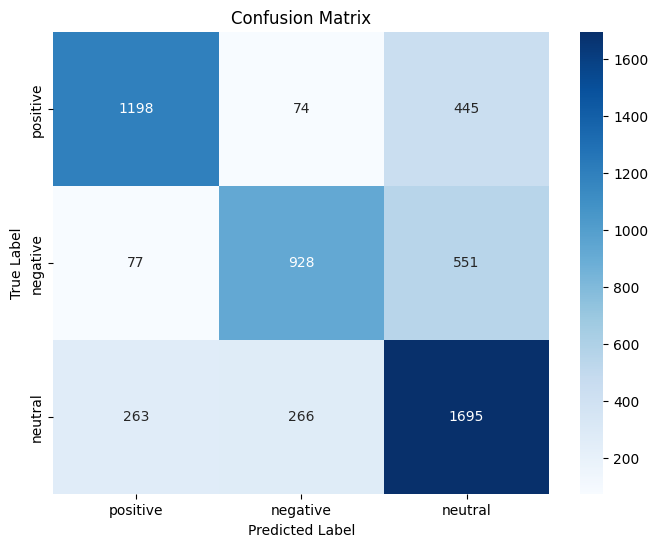


--- K-Nearest Neighbors Model Evaluation ---
Accuracy: 0.4823

Classification Report (KNN):
              precision    recall  f1-score   support

    negative       0.52      0.24      0.33      1556
     neutral       0.45      0.82      0.58      2224
    positive       0.64      0.27      0.38      1717

    accuracy                           0.48      5497
   macro avg       0.54      0.44      0.43      5497
weighted avg       0.53      0.48      0.44      5497



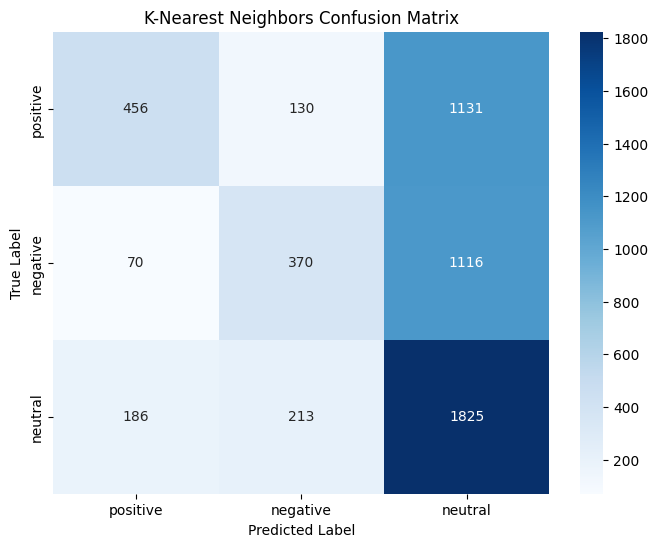


--- Support Vector Machine Model Evaluation ---
Accuracy: 0.6986

Classification Report (SVC):
              precision    recall  f1-score   support

    negative       0.76      0.58      0.66      1556
     neutral       0.62      0.80      0.70      2224
    positive       0.80      0.68      0.74      1717

    accuracy                           0.70      5497
   macro avg       0.73      0.69      0.70      5497
weighted avg       0.72      0.70      0.70      5497



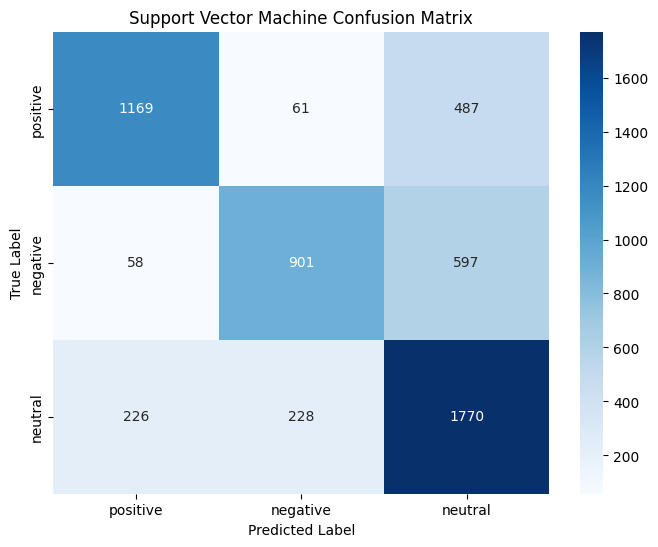


--- Random Forest Model Evaluation ---
Accuracy: 0.6966

Classification Report (Random Forest):
              precision    recall  f1-score   support

    negative       0.71      0.61      0.65      1556
     neutral       0.65      0.72      0.69      2224
    positive       0.75      0.75      0.75      1717

    accuracy                           0.70      5497
   macro avg       0.70      0.69      0.70      5497
weighted avg       0.70      0.70      0.70      5497



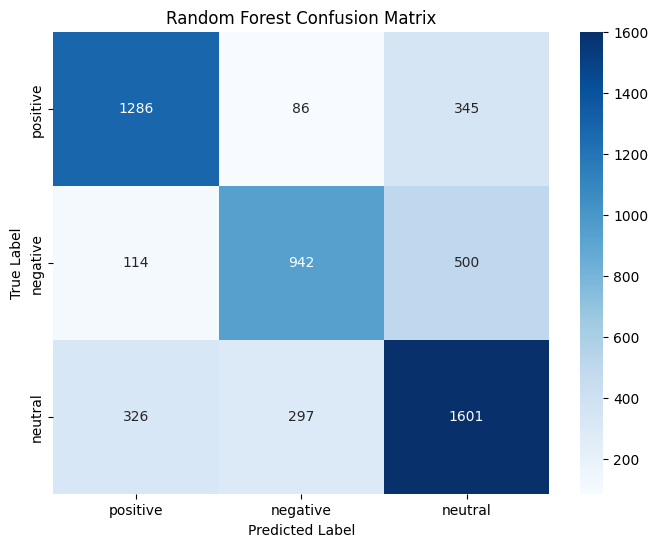

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Predict on the test set
y_pred_numeric = log_reg_model.predict(X_test_tfidf)
# Convert numeric predictions back to original labels for better readability
# Create a reverse mapping
reverse_sentiment_mapping = {v: k for k, v in sentiment_mapping.items()}
y_test_labels = y_test.map(reverse_sentiment_mapping)
y_pred_labels = pd.Series(y_pred_numeric).map(reverse_sentiment_mapping)
print("\n--- Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test_labels, y_pred_labels):.4f}")
print("\nClassification Report(Logistic Regression):")
print(classification_report(y_test_labels, y_pred_labels))
# Confusion Matrix
cm = confusion_matrix(y_test_labels, y_pred_labels, labels=list(sentiment_mapping.keys()))
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
xticklabels=list(sentiment_mapping.keys()),
yticklabels=list(sentiment_mapping.keys()))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


y_pred_knn_numeric = knn_model.predict(X_test_tfidf)
y_pred_knn_labels = pd.Series(y_pred_knn_numeric).map(reverse_sentiment_mapping)

print("\n--- K-Nearest Neighbors Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test_labels, y_pred_knn_labels):.4f}")

print("\nClassification Report (KNN):")
print(classification_report(y_test_labels, y_pred_knn_labels))

cm_knn = confusion_matrix(y_test_labels, y_pred_knn_labels, labels=list(sentiment_mapping.keys()))
plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(sentiment_mapping.keys()),
            yticklabels=list(sentiment_mapping.keys()))
plt.title('K-Nearest Neighbors Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


y_pred_svc_numeric = svc_model.predict(X_test_tfidf)
y_pred_svc_labels = pd.Series(y_pred_svc_numeric).map(reverse_sentiment_mapping)

print("\n--- Support Vector Machine Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test_labels, y_pred_svc_labels):.4f}")

print("\nClassification Report (SVC):")
print(classification_report(y_test_labels, y_pred_svc_labels))

cm_svc = confusion_matrix(y_test_labels, y_pred_svc_labels, labels=list(sentiment_mapping.keys()))
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svc, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(sentiment_mapping.keys()),
            yticklabels=list(sentiment_mapping.keys()))
plt.title('Support Vector Machine Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


y_pred_random_forest_numeric = random_forest_model.predict(X_test_tfidf)
y_pred_random_forest_labels = pd.Series(y_pred_random_forest_numeric).map(reverse_sentiment_mapping)

print("\n--- Random Forest Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test_labels, y_pred_random_forest_labels):.4f}")

print("\nClassification Report (Random Forest):")
print(classification_report(y_test_labels, y_pred_random_forest_labels))

cm_random_forest = confusion_matrix(y_test_labels, y_pred_random_forest_labels, labels=list(sentiment_mapping.keys()))
plt.figure(figsize=(8, 6))
sns.heatmap(cm_random_forest, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(sentiment_mapping.keys()),
            yticklabels=list(sentiment_mapping.keys()))
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


# Visualize and tabulate the results of model evaluation

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



--- Detailed Model Evaluation Table ---


,Model,Accuracy,Macro Avg Precision,Macro Avg Recall,Macro Avg F1-Score
0,LightGBM,0.700018,0.720559,0.688092,0.697174
1,SVC,0.698563,0.727289,0.685250,0.696964
2,Random Forest,0.696562,0.703519,0.691418,0.695539
3,Logistic Regression,0.695106,0.713557,0.685423,0.694349
4,K-Nearest Neighbors,0.482263,0.535855,0.441321,0.427110


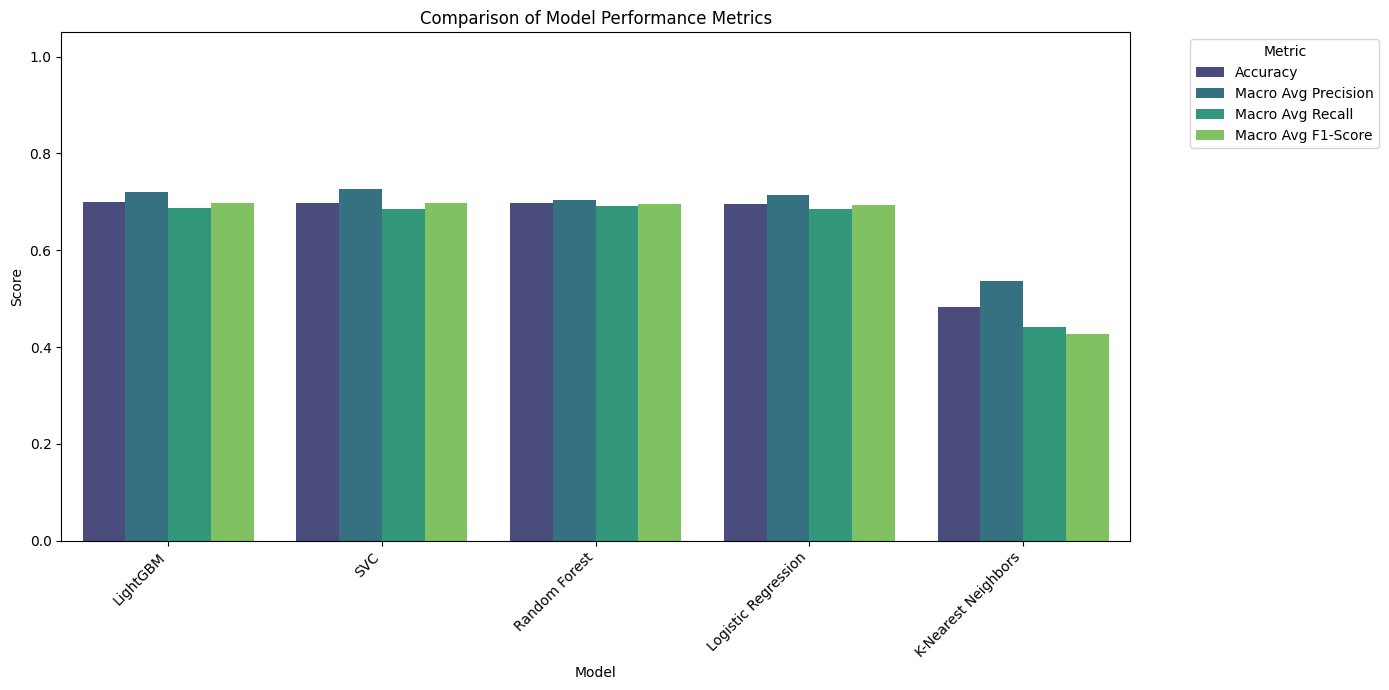

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import classification_report, accuracy_score

# Prepare lists to store all evaluation metrics
model_names = ['Logistic Regression', 'K-Nearest Neighbors', 'SVC', 'Random Forest', 'LightGBM']
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

# Mapping for numeric sentiment to labels for evaluation
reverse_sentiment_mapping = {v: k for k, v in sentiment_mapping.items()}
y_test_labels = y_test.map(reverse_sentiment_mapping)

# Evaluate each model and store metrics
models = {
    'Logistic Regression': log_reg_model,
    'K-Nearest Neighbors': knn_model,
    'SVC': svc_model,
    'Random Forest': random_forest_model,
    'LightGBM': lgbm_model
}

for name, model in models.items():
    # Make predictions
    y_pred_numeric = model.predict(X_test_tfidf)
    y_pred_labels = pd.Series(y_pred_numeric).map(reverse_sentiment_mapping)

    # Calculate metrics
    accuracy = accuracy_score(y_test_labels, y_pred_labels)
    report = classification_report(y_test_labels, y_pred_labels, output_dict=True)

    accuracy_scores.append(accuracy)
    precision_scores.append(report['macro avg']['precision'])
    recall_scores.append(report['macro avg']['recall'])
    f1_scores.append(report['macro avg']['f1-score'])

# Create a DataFrame for all evaluation metrics
evaluation_df_full = pd.DataFrame({
    'Model': model_names,
    'Accuracy': accuracy_scores,
    'Macro Avg Precision': precision_scores,
    'Macro Avg Recall': recall_scores,
    'Macro Avg F1-Score': f1_scores
})

# Sort by Accuracy for better presentation
evaluation_df_full = evaluation_df_full.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

print("\n--- Detailed Model Evaluation Table ---")
display(evaluation_df_full)

# Prepare data for plotting (melt DataFrame)
plot_df = evaluation_df_full.melt(id_vars='Model', var_name='Metric', value_name='Score')

# Create the grouped bar chart
plt.figure(figsize=(14, 7))
sns.barplot(x='Model', y='Score', hue='Metric', data=plot_df, palette='viridis')
plt.title('Comparison of Model Performance Metrics')
plt.ylabel('Score')
plt.xlabel('Model')
plt.ylim(0, 1.05) # Metrics are between 0 and 1
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# I/O (Perform input/output testing to validate the model's predictions)


In [ ]:
def predict_sentiment_all_models(raw_text):
    # 1. Preprocess the raw text
    cleaned_text = preprocess_text(raw_text)

    # 2. Transform the cleaned text using the fitted TF-IDF vectorizer
    # Ensure the input to transform is a list-like structure
    transformed_text_sparse = tfidf_vectorizer.transform([cleaned_text])

    # 3. Initialize a dictionary to store predictions
    predictions = {}

    # 4. Define the models and their names
    models = {
        'Logistic Regression': log_reg_model,
        'K-Nearest Neighbors': knn_model,
        'SVC': svc_model,
        'Random Forest': random_forest_model,
        'LightGBM': lgbm_model
    }

    # 5. Predict sentiment using each model and store the results
    for model_name, model in models.items():
        # For LightGBM, convert to dense array to avoid UserWarning about feature names
        if model_name == 'LightGBM':
            numeric_prediction = model.predict(transformed_text_sparse.toarray())[0]
        else:
            numeric_prediction = model.predict(transformed_text_sparse)[0]
        sentiment_label = reverse_sentiment_mapping[numeric_prediction]
        predictions[model_name] = sentiment_label
    return predictions



# Sample input text /////////////////////////INPUT\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\
user_input_text = 'I am so happy today! The sun is shining and I feel great.'
#user_input_text = " I go there for walk"



# Call the function with the sample input
all_model_predictions = predict_sentiment_all_models(user_input_text)

# Print the results
print(f"Sample Text: \n\n{user_input_text}\n")
print("Sentiment Predictions from all models:")
for model_name, prediction in all_model_predictions.items():
    print(f"  **{model_name}**: {prediction}")
print()

Sample Text: 

I am so happy today! The sun is shining and I feel great.

Sentiment Predictions from all models:
  **Logistic Regression**: positive
  **K-Nearest Neighbors**: negative
  **SVC**: positive
  **Random Forest**: positive
  **LightGBM**: positive



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
